# Wildfire Notable - Event Prediction
# Kirill Burin - 923357830
## Abstract

This project creates a framework to predict the occurrence of notable wildfires in the United States on a county/year/month basis using historical wildfire incident data from 1992 to 2015.

A notable wildfire is a fire that had a final size of 300+ acres. The raw data is aggregated to a county level and then lagged and rolling historical features are used to prevent time leakage.

Exploratory analysis indicates a high degree of seasonality and spatial variability in notable wildfire occurrence. Two models are compared: a baseline model using logistic regression and a more flexible XGBoost model.

Expanding window time-aware cross-validation is used to evaluate the models on a time series basis, using AUC as a metric. Logistic regression outperformed XGBoost under time-aware validation. The results show that the baseline model actually performs slightly better than XGBoost, indicating that a simpler and more interpretable model is competitive for the task.

## 1. Data Preprocessing

In the following section, we will discuss the process of transforming the raw wildfire incident table into a county by year-month dataset, which is used for prediction by combining the wildfire records with the county by year-month data.

We will discuss the following:

How the notable fires are identified and filtered

How the space-time units are constructed (county by year-month)

How the binary outcome is constructed

How the predictors are constructed (lagged to avoid leakage)

How the missing data is handled

### Goal:

The creation of a modeling-ready dataset that has one row per county-year-month and a binary outcome variable.

The outcome variable Y, which indicates if at least one notable fire (300 acres or more) occurs in a given county in a given month and year.

The predictors are all based only on information available in the preceding months or preceding years. This ensures that the modeling setup does not suffer from any form of temporal leakage.



### Load Data
Most Important Variables: 
* LATITUDE, LONGITUDE: Ignition location (decimal degrees)
* FIRE_SIZE: Final fire size (acres)
* STATE: State in which the fire burned
* FIPS_CODE: code of the county 3 digits
* DISCOVERY_DOY: Day-of-year the fire was discovered


The code for loading the full dataset (1.88 million observations) is included but currently commented out.

In [288]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import geopandas as gpd
import scipy.sparse as sp

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report, confusion_matrix)

from xgboost import XGBClassifier


#conn = sqlite3.connect("/Users/kirillburin/Downloads/FPA_FOD_20170508.sqlite")
#df = pd.read_sql_query("SELECT * FROM Fires;", conn)
df = pd.read_csv("wildfires_sample_100k.csv", low_memory=False)


### Handling Missing Data and Creating Useful Columns
The variable month is created by extracting the DISCOVERY_DOY, a full county identifier is created by combining the state code with the county FIPS code, and missing county FIPS codes are filled by a US county shapefile from Data.gov for the year 2015, so that the longitude and latitude are matched to the county boundaries, enabling each wildfire to be allocated a county.



In [289]:
# Creating Month Column
df["DISCOVERY_DOY"] = df["DISCOVERY_DOY"].astype("string").str.zfill(3)
df["FIRE_DATE"] = df["FIRE_YEAR"].astype("string") + df["DISCOVERY_DOY"]
df["FIRE_DATE"] = pd.to_datetime(df["FIRE_DATE"], format="%Y%j")
df["MONTH"] = df["FIRE_DATE"].dt.month

# Creating Full FIPS Code for each county
# Connecting FIPS code for state + FIPS for county to get the final 5 digit FIPS code on existing data. 
state_codes = {
    'WA': '53', 'DE': '10', 'DC': '11', 'WI': '55', 'WV': '54', 'HI': '15',
    'FL': '12', 'WY': '56', 'PR': '72', 'NJ': '34', 'NM': '35', 'TX': '48',
    'LA': '22', 'NC': '37', 'ND': '38', 'NE': '31', 'TN': '47', 'NY': '36',
    'PA': '42', 'AK': '02', 'NV': '32', 'NH': '33', 'VA': '51', 'CO': '08',
    'CA': '06', 'AL': '01', 'AR': '05', 'VT': '50', 'IL': '17', 'GA': '13',
    'IN': '18', 'IA': '19', 'MA': '25', 'AZ': '04', 'ID': '16', 'CT': '09',
    'ME': '23', 'MD': '24', 'OK': '40', 'OH': '39', 'UT': '49', 'MO': '29',
    'MN': '27', 'MI': '26', 'RI': '44', 'KS': '20', 'MT': '30', 'MS': '28',
    'SC': '45', 'KY': '21', 'OR': '41', 'SD': '46'}

df["FIPS_CODE"] = df["FIPS_CODE"].astype("Int64")
df["FIPS_CODE"] = df["FIPS_CODE"].astype("string").str.zfill(3)
df["FIPS5"] = df["STATE"].map(state_codes).astype("string")+df["FIPS_CODE"]

# Finding the missing FIPS codes by longitude and latitude
counties = gpd.read_file("tl_2015_us_county/tl_2015_us_county.shp") # requirments.txt to reproduce the file dowlowload it from https://www.census.gov/cgi-bin/geo/shapefiles/index.php
coordinates = df.loc[df["FIPS_CODE"].isna(),["LONGITUDE","LATITUDE"]]

points = gpd.GeoDataFrame(
    coordinates.copy(),
    geometry=gpd.points_from_xy(coordinates["LONGITUDE"], coordinates["LATITUDE"]),
    crs=counties.crs)

matched = gpd.sjoin(
    points,
    counties[["GEOID", "geometry"]],
    how="left",
    predicate="within")

df.loc[matched.index, "FIPS5"] = matched["GEOID"]
df["FIPS5"] = df["FIPS5"].replace({"12025": "12086"}) # In november 1997 FIPS code of Dade County Florida was changed from 12025 to 12086

# By this point all of our missing FIPS rows are filled, matched by Longitude and Latidude. 



### Defining Notable Fires and the Outcome Variable

We define “notable” fires to be those with a final size of at least 300 acres, which is a reasonable definition based on common operational thresholds used for large fire reporting.

The incident-level wildfire data is then aggregated into a county year month table.

We then define a binary outcome variable Y, which is equal to 1 if there was at least one notable fire in a county during a particular month and year, and 0 otherwise. At this point, we have a table of observed wildfire incidents aggregated to the county year month level, but we have not yet added all possible county year month combinations.

In [290]:
# Filtering the notable Fires all of Notable fires are above 300 acres. 
df["FIRE300"] = (df["FIRE_SIZE"] >= 300).astype(int)

# Changing our data from one row each fire to one row each County x Month x Year
county_month = (
    df.groupby(["FIPS5", "FIRE_YEAR", "MONTH"])
      .agg(
          TOTAL_FIRES=("FIRE_SIZE", "size"),
          N_FIRES_ABOVE_300=("FIRE300", "sum")).reset_index())

# Creating our binary variable if notable fires are present Y = 1 else Y = 0 
county_month["Y"] = (county_month["N_FIRES_ABOVE_300"] > 0).astype(int)
print(f"Total Notable Fires: {(df['FIRE300'] == 1).sum()}")
print(f"County-months in which at least one notable fire occurred: {county_month['Y'].sum()}")
print(f"There are {county_month['Y'].sum()} observations where Y = 1")


Total Notable Fires: 1381
County-months in which at least one notable fire occurred: 1299
There are 1299 observations where Y = 1


### Constructing the Full County-Year-Month Panel and Prediction Table

In [291]:
# Extracting all counties even those where fires didn't happen, because if fire didn't happen at all, it isn't in our Kaggle dataset, we want to predict across all counties!
all_counties = counties["GEOID"].drop_duplicates()
all_years = df["FIRE_YEAR"].drop_duplicates()
all_months = range(1, 13)

# Making all possible combinations for all County x Month x Year
all_combos = pd.MultiIndex.from_product(
    [all_counties, all_years, all_months],
    names=["FIPS5", "FIRE_YEAR", "MONTH"]
).to_frame(index=False)

# Merging our transformed dataset with all possible combinations above, filling with zeros where no notable fires. 
full_table = pd.merge(all_combos, county_month, on=["FIPS5", "FIRE_YEAR", "MONTH"], how = "left")
full_table["N_FIRES_ABOVE_300"] = full_table["N_FIRES_ABOVE_300"].fillna(0)
full_table["TOTAL_FIRES"] =full_table["TOTAL_FIRES"].fillna(0).astype(int)
full_table["Y"] = full_table["Y"].fillna(0).astype(int).astype(int)

# Creating Predictors 0 = no notable fire, 1 = notable fire was present. 
full_table = full_table.sort_values(["FIPS5", "FIRE_YEAR", "MONTH"])
full_table["prev_month"] = full_table.groupby("FIPS5")["Y"].shift(1).fillna(0).astype(int)
full_table["last_year_this_month"] = full_table.groupby("FIPS5")["Y"].shift(12).fillna(0).astype(int)
full_table["large_fire_count_last_month"] = full_table.groupby("FIPS5")["N_FIRES_ABOVE_300"].shift(1).fillna(0).astype(int)
full_table["large_fire_count_last_year"] = full_table.groupby("FIPS5")["N_FIRES_ABOVE_300"].shift(12).fillna(0).astype(int)
full_table["fire_roll3"] = (
    full_table.groupby("FIPS5")["Y"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
    .fillna(0)
)
# Extra Predictors(For XGboost)
full_table["fire_roll12"] = (
    full_table.groupby("FIPS5")["Y"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=1).sum())
    .fillna(0))

full_table["size_roll3"] = (
    full_table.groupby("FIPS5")["N_FIRES_ABOVE_300"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
    .fillna(0))

full_table["size_roll12"] = (
    full_table.groupby("FIPS5")["N_FIRES_ABOVE_300"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=1).sum())
    .fillna(0))

full_table["total_fires_last_month"] = (
    full_table.groupby("FIPS5")["TOTAL_FIRES"].shift(1).fillna(0))

full_table["total_fires_last_year"] = (
    full_table.groupby("FIPS5")["TOTAL_FIRES"].shift(12).fillna(0))

# Getting our predictor table with only the data we are going to use for predictions, dropping wrong predictors to prevent leackage. 
prediction_table = full_table.drop(columns = ["N_FIRES_ABOVE_300","TOTAL_FIRES"])
# Creating a summary table 
pd.set_option("display.max_colwidth", None)

summary = pd.DataFrame({
    "Field": ["Total rows", "Years", "Spatial unit", "Temporal unit", 
              "Outcome", "Y=1 (fire)", "Y=0 (no fire)", "Predictors"],
    "Value": [
        len(prediction_table),
        f"{prediction_table.FIRE_YEAR.min()} – {prediction_table.FIRE_YEAR.max()}",
        "County (FIPS5)",
        "Month",
        "Y = 1 if any notable fire (≥300 acres) in county-month",
        f"{(prediction_table.Y == 1).sum()} ({(prediction_table.Y == 1).mean()*100:.2f}%)",
        f"{(prediction_table.Y == 0).sum()} ({(prediction_table.Y == 0).mean()*100:.2f}%)",
        "prev_month, last_year_this_month, large_fire_count_last_month,\n large_fire_count_last_year, fire_roll3, fire_roll12,\n size_roll3, size_roll12, total_fires_last_month, total_fires_last_year"
    ]
})

summary.set_index("Field").style.set_properties(**{
    "vertical-align": "middle",
    "white-space": "pre-wrap"
})



,Value
Field,
Total rows,931104
Years,1992 – 2015
Spatial unit,County (FIPS5)
Temporal unit,Month
Outcome,Y = 1 if any notable fire (≥300 acres) in county-month
Y=1 (fire),1299 (0.14%)
Y=0 (no fire),929805 (99.86%)
Predictors,"prev_month, last_year_this_month, large_fire_count_last_month, large_fire_count_last_year, fire_roll3, fire_roll12, size_roll3, size_roll12, total_fires_last_month, total_fires_last_year"


## 2. Exploratory Data Analysis 
This section attempts to examine the patterns of notable wildfire activities over time and space. The aim is to identify some trends in the occurrence of wildfires and use them to justify the modeling decisions made throughout the project.

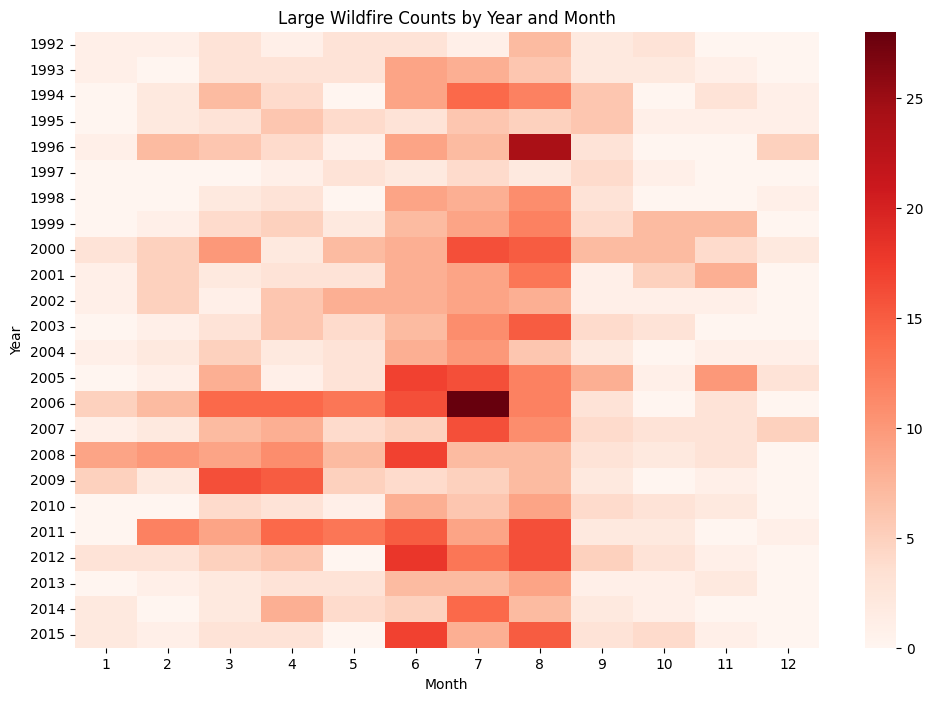

In [292]:
# Creating First Plot
heat = full_table.pivot_table(index = "FIRE_YEAR", columns = "MONTH", values = "N_FIRES_ABOVE_300", aggfunc="sum", fill_value=0)
plt.figure(figsize=(12, 8))
sns.heatmap(heat, cmap="Reds")
plt.title("Large Wildfire Counts by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()



### Seasonality Heatmap

The above heat map illustrates the number of fires that occurred over the years, month by month. From the heat map, we can see that the darkest shades fall in the summer months, especially June, July, and August. In contrast, in the winter months, the number of wildfires that occurred is relatively fewer. A strong seasonality pattern can also be observed in the heat map, where the month in the middle of the year had some significant number of fires. Therefore, the month was used as a predictor in the modeling process.

Also, from the heat map above, we can see that the number of wildfires that occurred varies over the years. For example, in the years 1996, 2000, 2006, 2011, and 2012, the number of significant wildfires was relatively higher. This also points to the use of the year in the modeling process.




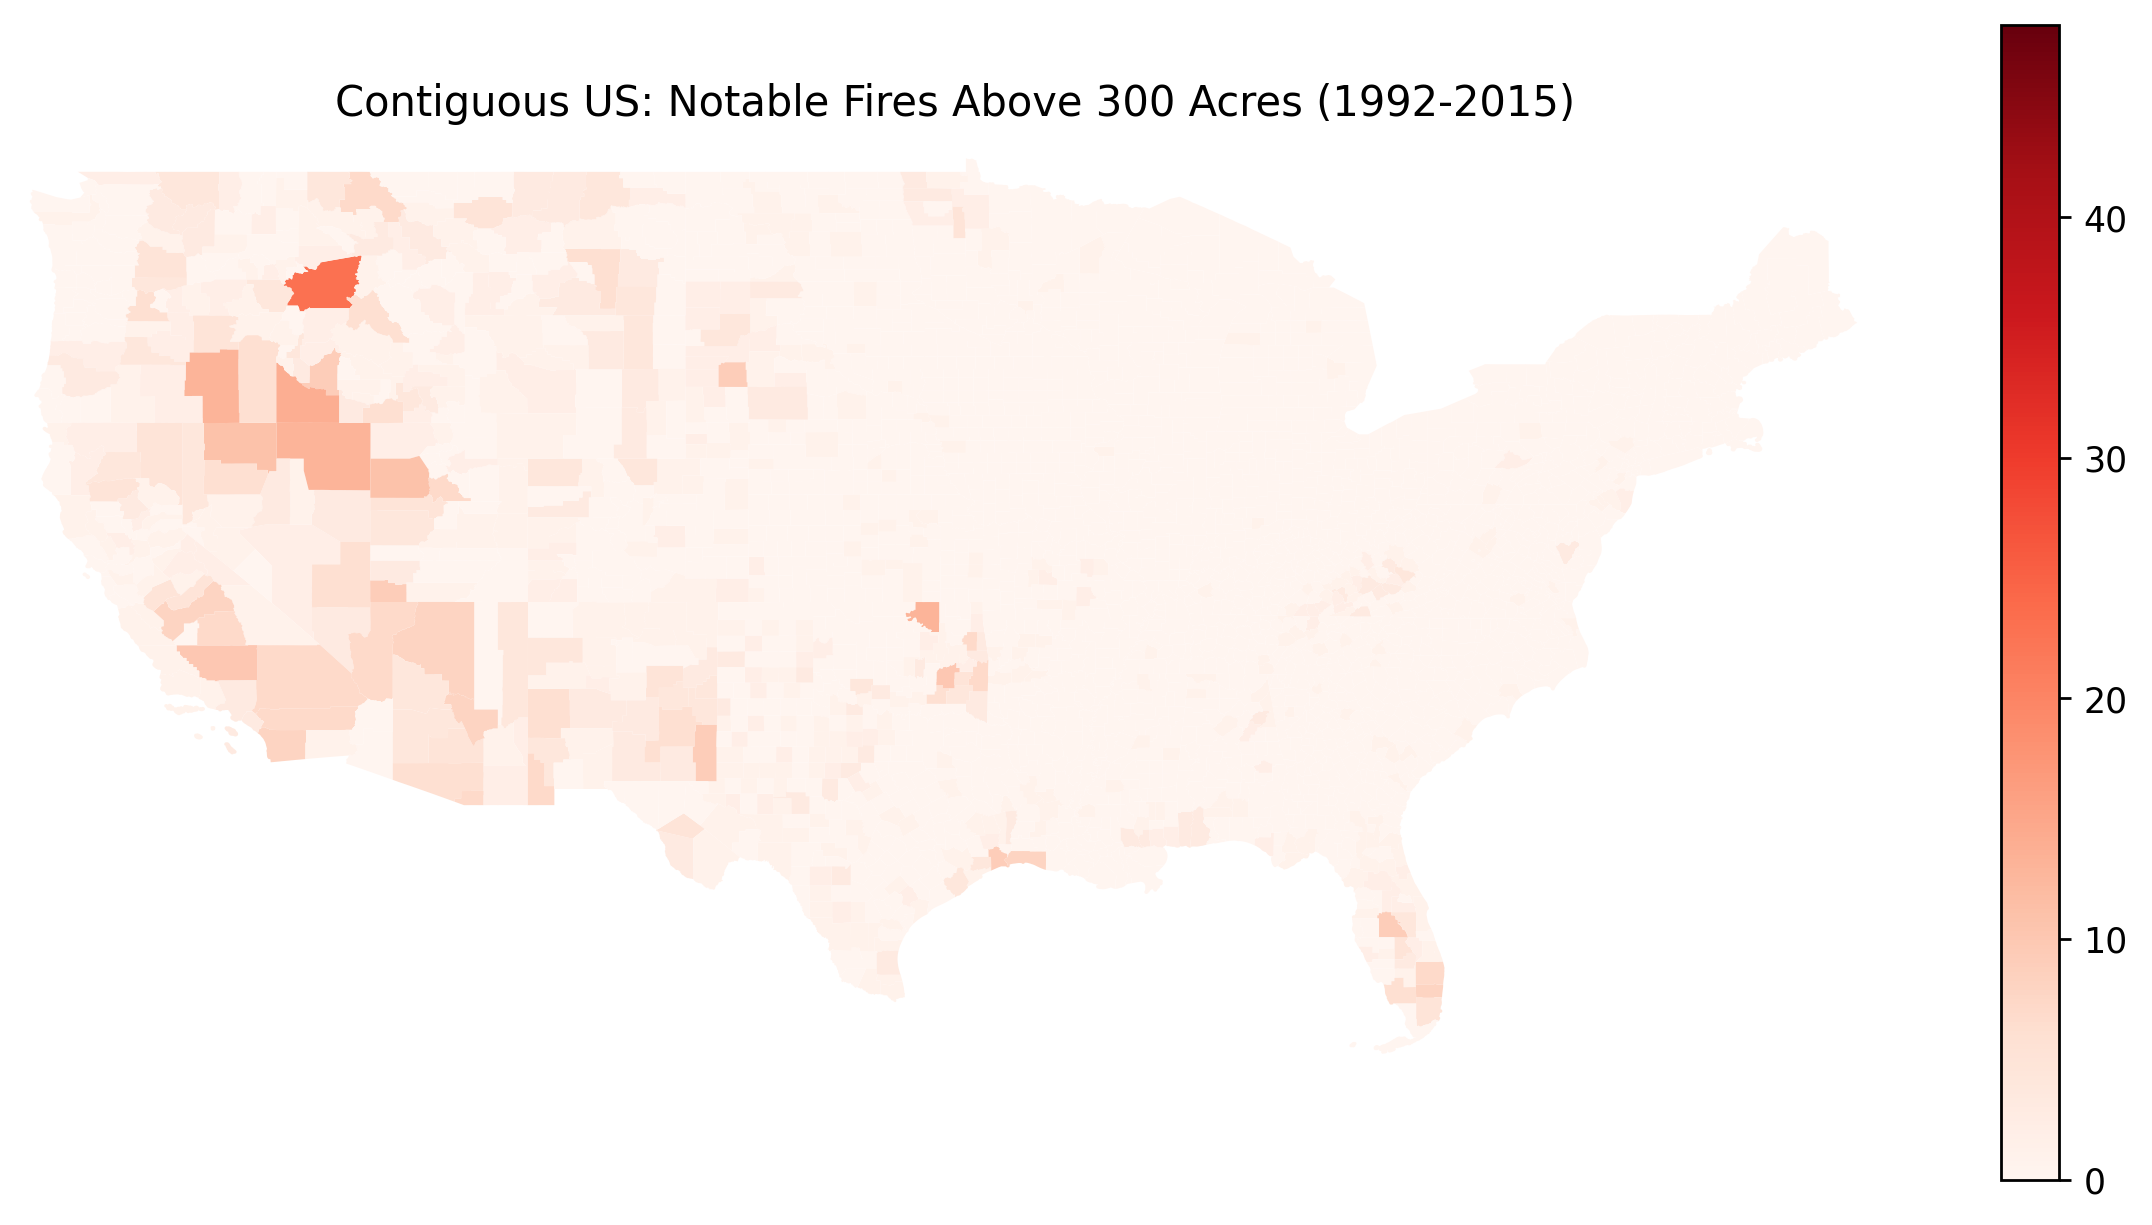

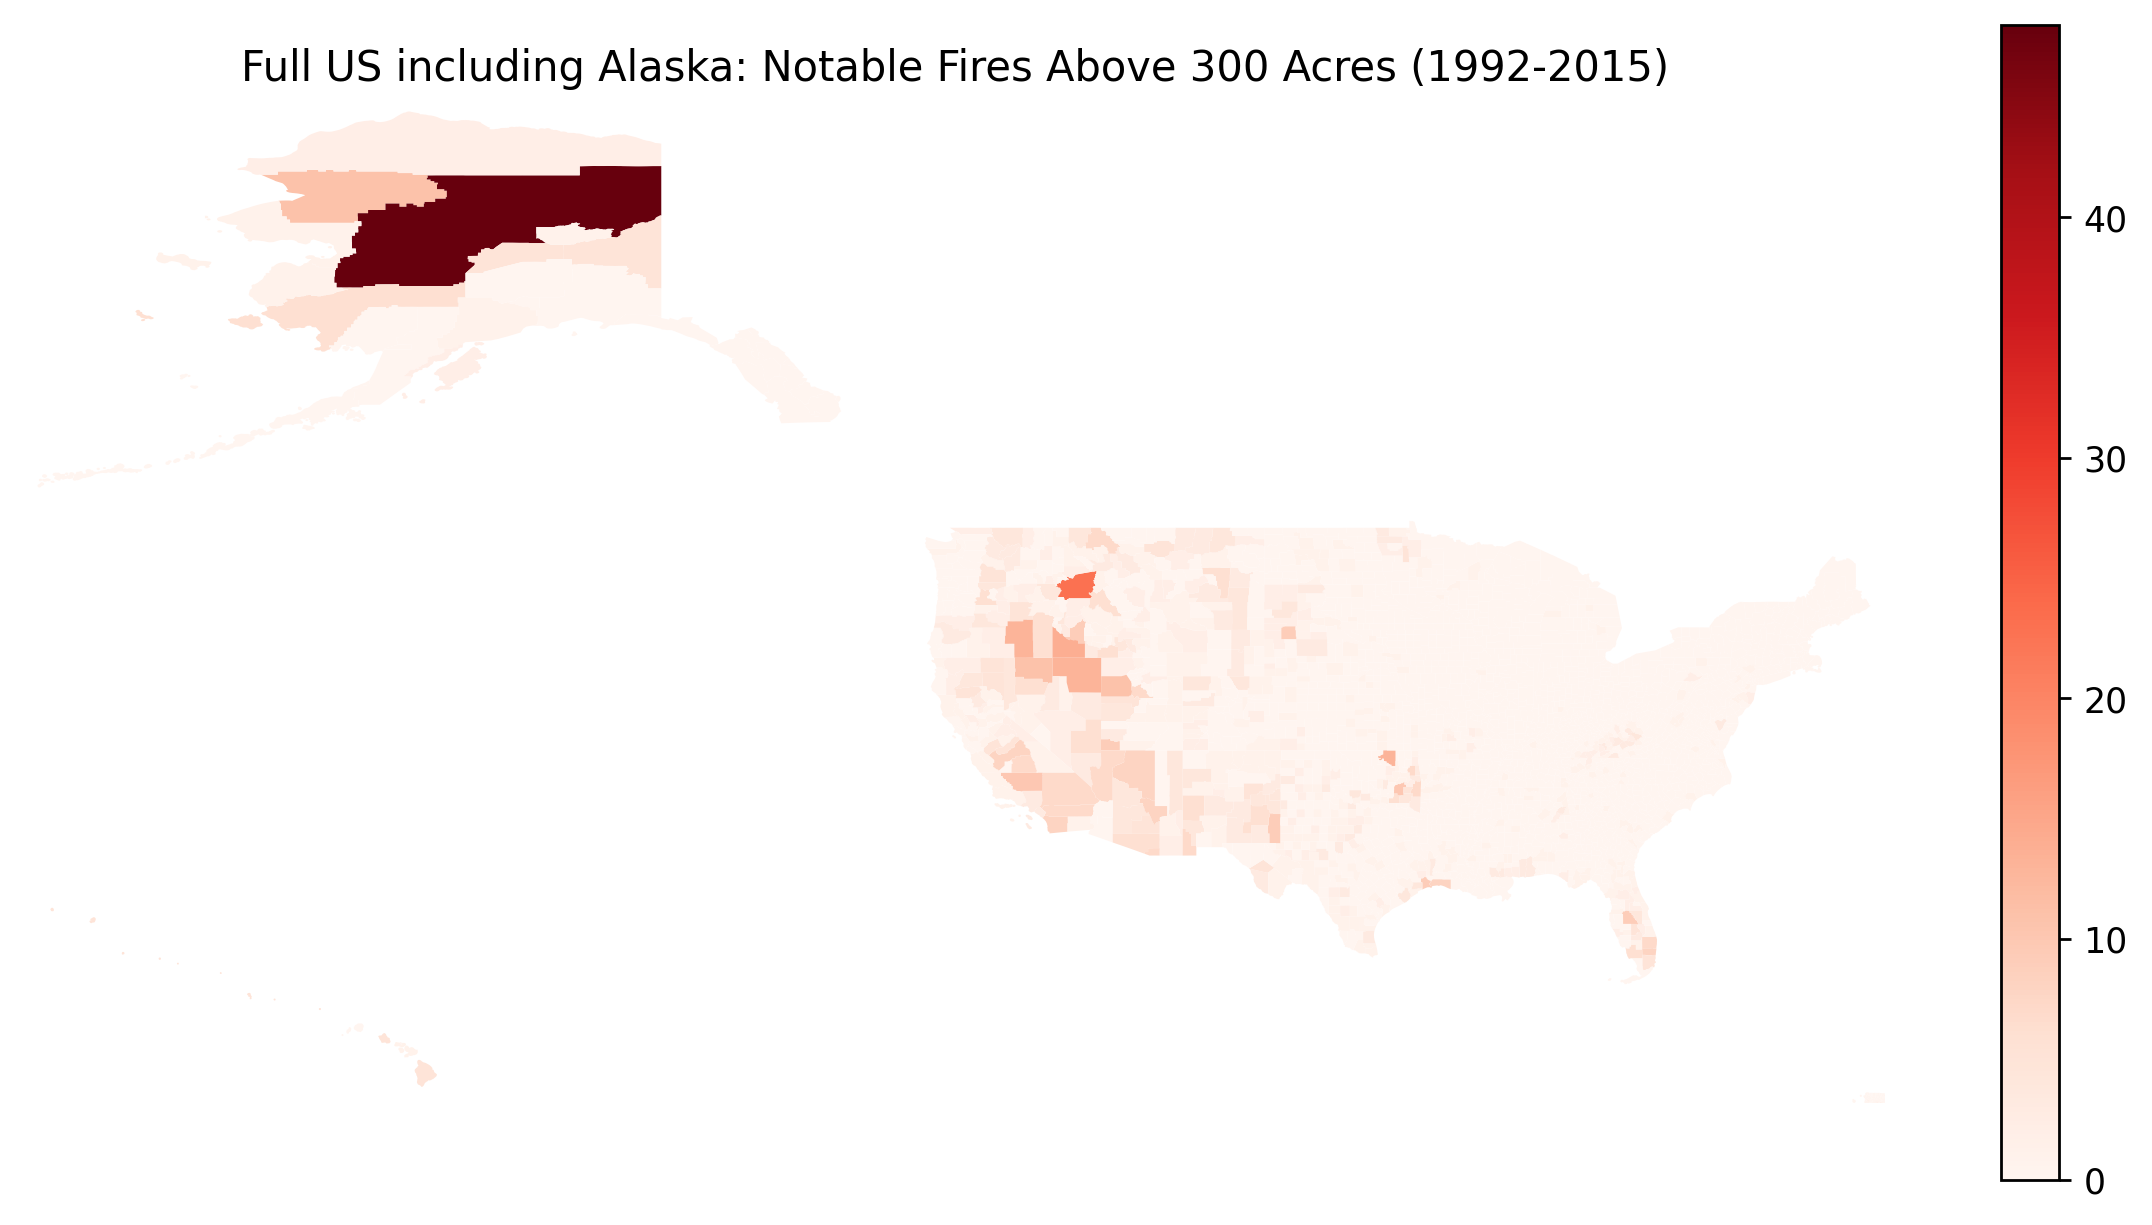

In [293]:
# Preparing Data for Chrolopleth for all years all months filtered by county
fires_counts = full_table.groupby("FIPS5")["N_FIRES_ABOVE_300"].sum()
chrolopleth = pd.merge(counties, fires_counts, left_on = "GEOID", right_on = "FIPS5", how="left")


# Creating the second Plot
fig, ax = plt.subplots(figsize=(12, 6), dpi=250)
chrolopleth.plot(
    column = "N_FIRES_ABOVE_300",
    cmap="Reds",
    legend=True,
    ax=ax)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis("off")
plt.title("Contiguous US: Notable Fires Above 300 Acres (1992-2015)")
plt.show()
# with ALaska
fig, ax = plt.subplots(figsize=(12, 6), dpi=250)

chrolopleth.plot(
    column = "N_FIRES_ABOVE_300",
    cmap="Reds",
    legend=True,
    ax=ax)
ax.set_xlim(-180, -66)
ax.set_ylim(18, 72)
ax.axis("off")
plt.title("Full US including Alaska: Notable Fires Above 300 Acres (1992-2015)")
plt.show()

### Spatial Choropleth

This choropleth map shows significant geographical variation in the number of prominent wildfires by U.S. counties between 1992 and 2015. The highest number of prominent wildfires is observed in Alaska and some regions of the western United States, while the majority of counties in the central and eastern United States have low levels of prominent wildfire occurrences. These observations indicate that prominent wildfires are not uniformly distributed across geographical space.

The map further indicates a strong regional pattern with significantly high wildfire occurrences in some western counties and Alaskan regions. Between 1992 and 2015, Alaska had more large wildfires than the Lower 48 due to the massive and sparsely populated boreal forests that allowed lightning-caused fires to burn for weeks with little or no human intervention. Moreover, the Arctic region has been warming at a high rate, drying out deep layers of moss and peat, which have become a massive fuel source that remains flammable well into the fire season.

In contrast, there were few or no prominent wildfires in many counties in the Midwest and Northeast regions. Due to the large variability in the number of notable wildfires among counties, the county-level location was added to the models using the FIPS5 variable.

From the figure, it is evident that the occurrence of prominent wildfires is not evenly distributed across the United States. The geographic distribution of the data was one of the reasons why county-level location information was added to the model.




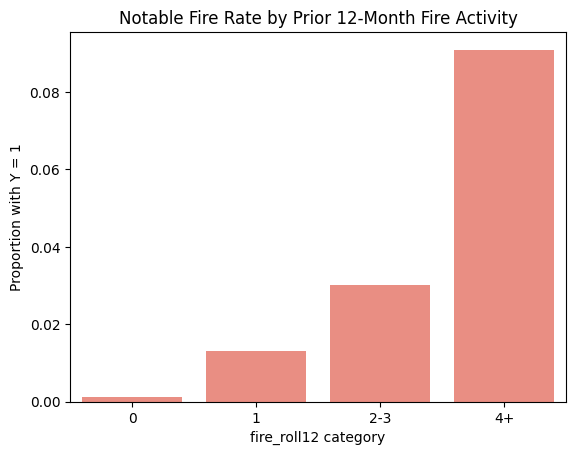

In [294]:
plot_df = prediction_table[["Y", "fire_roll12"]].copy()

plot_df["fire_roll12_bin"] = pd.cut( plot_df["fire_roll12"], bins=[-0.1, 0.5, 1.5, 3.5, float("inf")], labels=["0", "1", "2-3", "4+"])

rate_df = (plot_df.groupby("fire_roll12_bin", observed=True).agg(event_rate=("Y", "mean"), n=("Y", "size")).reset_index())

ax = sns.barplot(
    data=rate_df,
    x="fire_roll12_bin",
    y="event_rate",
    color="salmon")

plt.title("Notable Fire Rate by Prior 12-Month Fire Activity")
plt.xlabel("fire_roll12 category")
plt.ylabel("Proportion with Y = 1")
plt.show()




### Prior Fire Activity Bar Plot

This bar plot shows that as the number of notable fires in the previous 12 months increases, the probability of a notable fire in the current month also increases. County-year-month observations with no notable fires in the previous 12 months have a very low event rate, while observations with 4 or more notable fires in the previous 12 months have a much higher event rate.
This suggests that recent wildfire history is strongly associated with current wildfire occurrence. It also supports the use of rolling and other lagged historical fire variables as predictors in the models. 

## Section 3: Modeling

We fit two predictive models for binary wildfire occurrence.

Logistic Regression: A straightforward and interpretable baseline model based on 7 predictors to set a benchmark for forecasting whether a significant wildfire event will take place in a given county-year-month observation. The model is based on county, month, year, and lag wildfire history variables. In this model, FIPS5 and MONTH are considered categorical predictors. A logistic regression model is a natural choice for a baseline model since it is easy to interpret, performs well with binary outcomes, and provides a useful benchmark against which more complex nonlinear models can be compared.
$$
\text{logit}(P(Y_{c,t} = 1)) = \beta_0 + \beta_1 \text{FIPS5} + \beta_2 \text{MONTH} + \beta_3 \text{FIRE\_YEAR} + \beta_4 \text{prev\_month}
$$
$$
+ \beta_5 \text{last\_year\_this\_month} + \beta_6 \text{large\_fire\_count\_last\_month} + \beta_7 \text{large\_fire\_count\_last\_year}
$$

where:

- $\text{logit}(P(Y_{c,t} = 1))$ — log-odds of a fire occurring in county $c$ at time $t$  
- $\beta_0$ — intercept  
- $\beta_1\ \text{FIPS5}$ — county-level fixed effect  
- $\beta_2\ \text{MONTH}$ — month of the year (seasonality)  
- $\beta_3\ \text{FIRE\_YEAR}$ — year of observation  
- $\beta_4\ \text{prev\_month}$ — fire activity in the previous month  
- $\beta_5\ \text{last\_year\_this\_month}$ — fire activity in the same month last year  
- $\beta_6\ \text{large\_fire\_count\_last\_month}$ — count of large fires in the prior month  
- $\beta_7\ \text{large\_fire\_count\_last\_year}$ — count of large fires in the prior year

XGBoost: A gradient boosting algorithm that employs 12 predictors. This model was chosen because the occurrence of wildfires could be a function of complex interactions and threshold values of seasonal and historical fire variables that may not be adequately modeled by logistic regression. In addition to the control predictors, the XGBoost model also incorporates additional rolling and lagged fire history variables, such as short-term and long-term rolling counts of past fires and lagged total fire activity. These additional predictors were added to enable the model to better capture complex temporal relationships of wildfire activity.

The predicted output $\hat{y}_i$ for sample $i$ is defined as the sum of $M$ additive functions:

$$
\hat{y}_i = \sum_{m=1}^{M} f_m(x_i), \quad f_m \in \mathcal{F}
$$

where:

- $\hat{y}_i$ — predicted value for the $i$-th sample  
- $M$ — total number of trees (boosting rounds)  
- $f_m$ — the $m$-th tree (weak learner)  
- $x_i$ — feature vector for sample $i$  
- $\mathcal{F}$ — the space of regression trees (CARTs) 

The prediction in XGBoost is done by aggregating different decision trees, where each decision tree is added to the model in order to reduce the mistakes that the previous ensemble of decision trees might have made. This enables the model to handle non-linear relationships between the predictors in a flexible way.

## 4. Model Fitting and Validation

Validation respects the temporal structure through an expanding-window cross-validation procedure. For each fold:

Train on all observations from years ≤t

Validate on observations from year t+1

Begin with at least 3 years of training data

For both models, we report:

Cross-validated AUC

A diagnostic plot of AUC across validation years

Cross-validated confusion matrices

Cross-validated classification reports based on out-of-fold predictions

Mean CV AUC by model


,mean,std,min,max
model,,,,
Logistic Regression,0.792073,0.054362,0.695115,0.866566
XGBoost,0.778277,0.046798,0.694097,0.856935


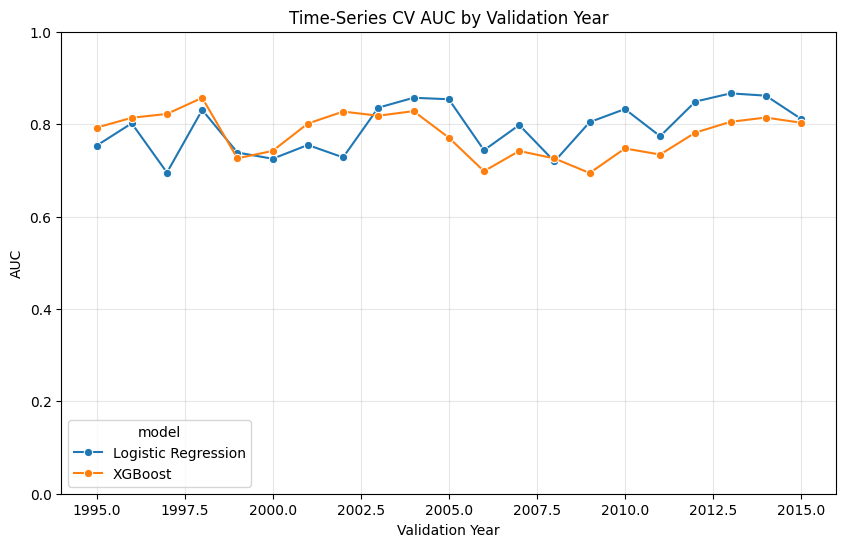

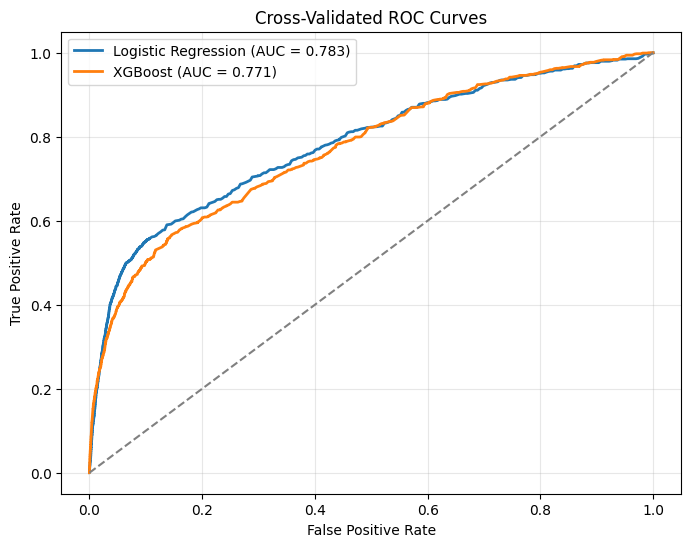


Logistic Regression
Cross-Validated AUC: 0.7832
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    813530
           1       0.01      0.55      0.02      1186

    accuracy                           0.90    814716
   macro avg       0.50      0.73      0.48    814716
weighted avg       1.00      0.90      0.95    814716

Confusion Matrix:
[[735441  78089]
 [   538    648]]


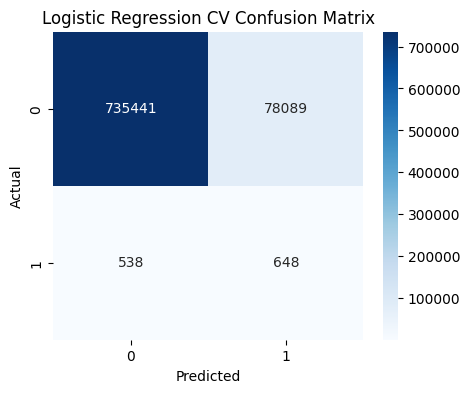


XGBoost
Cross-Validated AUC: 0.771
              precision    recall  f1-score   support

           0       1.00      0.86      0.93    813530
           1       0.01      0.55      0.01      1186

    accuracy                           0.86    814716
   macro avg       0.50      0.71      0.47    814716
weighted avg       1.00      0.86      0.92    814716

Confusion Matrix:
[[701258 112272]
 [   528    658]]


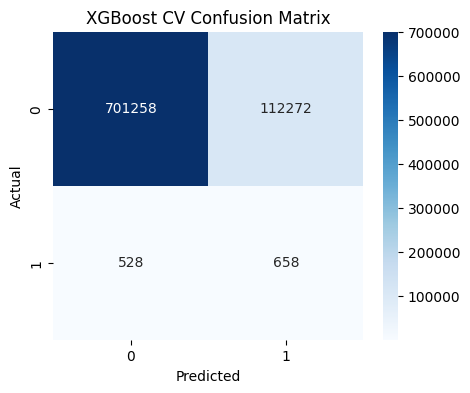

In [295]:

# CV only: use all years
cv_data = prediction_table.copy()
cv_data = cv_data.sort_values(["FIRE_YEAR", "MONTH", "FIPS5"]).reset_index(drop=True)

years_sorted = sorted(cv_data["FIRE_YEAR"].unique())
min_train_years = 3

cat_features = ["FIPS5", "MONTH"]

# Simpler baseline feature set
lr_num_features = [
    "FIRE_YEAR",
    "prev_month",
    "last_year_this_month",
    "large_fire_count_last_month",
    "large_fire_count_last_year",
]

# Richer feature set for XGBoost
xgb_num_features = [
    "FIRE_YEAR",
    "prev_month",
    "last_year_this_month",
    "large_fire_count_last_month",
    "large_fire_count_last_year",
    "fire_roll3",
    "fire_roll12",
    "size_roll3",
    "size_roll12",
    "total_fires_last_month",
    "total_fires_last_year",
]

target = "Y"

fold_metrics = []
oof_predictions = {
    "Logistic Regression": [],
    "XGBoost": [],
}

for end_idx in range(min_train_years - 1, len(years_sorted) - 1):
    train_end_year = years_sorted[end_idx]
    valid_year = years_sorted[end_idx + 1]

    train_fold = cv_data[cv_data["FIRE_YEAR"] <= train_end_year]
    valid_fold = cv_data[cv_data["FIRE_YEAR"] == valid_year]

    y_train = train_fold[target].to_numpy()
    y_valid = valid_fold[target].to_numpy()

    # One-hot categorical features for both models
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    X_train_cat = ohe.fit_transform(train_fold[cat_features])
    X_valid_cat = ohe.transform(valid_fold[cat_features])

    # Logistic branch: scaled numeric features
    scaler_lr = StandardScaler()
    X_train_lr_num = scaler_lr.fit_transform(train_fold[lr_num_features])
    X_valid_lr_num = scaler_lr.transform(valid_fold[lr_num_features])

    X_train_lr = sp.hstack([X_train_cat, sp.csr_matrix(X_train_lr_num)], format="csr")
    X_valid_lr = sp.hstack([X_valid_cat, sp.csr_matrix(X_valid_lr_num)], format="csr")

    lr_model = LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    )
    lr_model.fit(X_train_lr, y_train)

    lr_prob = lr_model.predict_proba(X_valid_lr)[:, 1]
    lr_pred = (lr_prob >= 0.5).astype(int)
    lr_auc = roc_auc_score(y_valid, lr_prob)

    fold_metrics.append({
        "model": "Logistic Regression",
        "train_end_year": int(train_end_year),
        "valid_year": int(valid_year),
        "auc": lr_auc,
    })

    oof_predictions["Logistic Regression"].append(
        pd.DataFrame({
            "model": "Logistic Regression",
            "train_end_year": int(train_end_year),
            "valid_year": int(valid_year),
            "y_true": y_valid,
            "y_prob": lr_prob,
            "y_pred": lr_pred,
        })
    )

    # XGBoost branch: one-hot categorical + richer numeric features
    X_train_xgb_num = train_fold[xgb_num_features].to_numpy()
    X_valid_xgb_num = valid_fold[xgb_num_features].to_numpy()

    X_train_xgb = sp.hstack([X_train_cat, sp.csr_matrix(X_train_xgb_num)], format="csr")
    X_valid_xgb = sp.hstack([X_valid_cat, sp.csr_matrix(X_valid_xgb_num)], format="csr")

    pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    xgb_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    xgb_model.fit(X_train_xgb, y_train)

    xgb_prob = xgb_model.predict_proba(X_valid_xgb)[:, 1]
    xgb_pred = (xgb_prob >= 0.5).astype(int)
    xgb_auc = roc_auc_score(y_valid, xgb_prob)

    fold_metrics.append({
        "model": "XGBoost",
        "train_end_year": int(train_end_year),
        "valid_year": int(valid_year),
        "auc": xgb_auc,
    })

    oof_predictions["XGBoost"].append(
        pd.DataFrame({
            "model": "XGBoost",
            "train_end_year": int(train_end_year),
            "valid_year": int(valid_year),
            "y_true": y_valid,
            "y_prob": xgb_prob,
            "y_pred": xgb_pred,
        })
    )

fold_results = pd.DataFrame(fold_metrics)

print("Mean CV AUC by model")
display(fold_results.groupby("model")["auc"].agg(["mean", "std", "min", "max"]))

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=fold_results,
    x="valid_year",
    y="auc",
    hue="model",
    marker="o"
)
plt.title("Time-Series CV AUC by Validation Year")
plt.xlabel("Validation Year")
plt.ylabel("AUC")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

oof_logistic = pd.concat(oof_predictions["Logistic Regression"], ignore_index=True)
oof_xgb = pd.concat(oof_predictions["XGBoost"], ignore_index=True)

plt.figure(figsize=(8, 6))
for model_name, oof_df in [
    ("Logistic Regression", oof_logistic),
    ("XGBoost", oof_xgb),
]:
    fpr, tpr, _ = roc_curve(oof_df["y_true"], oof_df["y_prob"])
    auc_value = roc_auc_score(oof_df["y_true"], oof_df["y_prob"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Cross-Validated ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for model_name, oof_df in [
    ("Logistic Regression", oof_logistic),
    ("XGBoost", oof_xgb),
]:
    print(f"\n{model_name}")
    print("Cross-Validated AUC:", round(roc_auc_score(oof_df["y_true"], oof_df["y_prob"]), 4))
    print(classification_report(oof_df["y_true"], oof_df["y_pred"], zero_division=0))

    cm = confusion_matrix(oof_df["y_true"], oof_df["y_pred"])
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} CV Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()





### Logistic Regression Validation Results

Logistic regression outperformed XGBoost under time-aware cross-validation.

Using expanding window cross-validation, the AUC of the logistic regression model was 0.7832. This means that, out of random selections of one positive county-year-month data point and one negative data point, the logistic regression model will predict higher probabilities for the positive data point 78.3% of the time. In terms of the ROC curve, we can say that the higher the curve is in the upper-left corner, the higher the performance of the curve. In this problem, the curve of the logistic regression model is higher than that of the XGBoost curve.

At the default classification threshold of 0.5, the logistic regression model produced the following confusion matrix:
True negatives: 735,441
False positives: 78,089
False negatives: 538
True positives: 648

These values correspond to an accuracy of 0.90. However, the accuracy needs to be viewed with caution due to the imbalanced nature of the data, where the majority of the samples are negative. As far as the positive class is concerned, the model reported precision of 0.01, recall of 0.55, and an F1-score of 0.02. The low precision value suggests that there was a significant amount of false alarms reported, which is typical of rare event prediction scenarios. The model was successful in reporting 55% of the positive samples, as suggested by the 0.55 reported for the recall metric. The F1-score remains low as it combines precision and recall. The precision was too low to allow the F1-score to be higher.

In this case, the logistic regression model is built using predictors FIPS5, MONTH, FIRE_YEAR, prev_month, last_year_this_month, large_fire_count_last_month, and large_fire_count_last_year. These predictors were chosen since they represent the major sources of variation in wildfires in a straightforward manner. FIPS5 is for county space, MONTH is for seasonality, FIRE_YEAR is for temporal variation, and the others are for recent wildfire history. Logistic regression is more likely to perform better than XGBoost in this situation since the probability of occurrence is very low, and the predictors will be sparse after one-hot encoding. In this situation, the logistic regression model is a strong and robust baseline.




### XGBoost Validation Results

For the expanded window cross-validation, the model had a cross-validated AUC of 0.7710. Although this is slightly lower than the AUC of the logistic regression model, which is 0.7832, this indicates that the XGBoost model had a slightly poorer overall discriminative ability. This can also be seen in the ROC curve, where the curve for the XGBoost model is consistently lower than the curve for the logistic regression model.

True negatives: 701,258
False positives: 112,272
False negatives: 528
True positives: 658

At the default classification threshold of 0.5, the confusion matrix of the XGBoost model contained 701,258 true negatives, 112,272 false positives, 528 false negatives, and 658 true positives. With this, the model achieved an overall accuracy of approximately 0.86, which was slightly lower than that of the logistic regression model. However, the model achieved lower accuracy compared to that of the logistic regression model. With regard to the positive class, the model achieved a precision of 0.01, recall of 0.55, and F1-score of 0.01. Although its recall was almost the same as that of the logistic regression model, the model generated many false positives, which affected its performance with regard to the positive class.

The XGBoost algorithm was trained with 13 predictors. This consisted of the 7 baseline predictors, as well as additional rolling and lag wildfire history predictors. This was to allow the XGBoost algorithm to pick up more complex temporal relationships in the data. However, XGBoost did not perform better than the logistic regression algorithm. This indicates that, for this data, the underlying predictive signal is already well captured by the simple approach of the logistic regression algorithm, while the additional flexibility of XGBoost did not allow it to generalize well with the time-aware validation.


# 5. Summary

Data Preprocessing and Feature Engineering

The wildfire data was changed into a format that shows information for each county over time with both months when fires happened and months when they did not.
We looked at fires, which are those that burned at least 300 acres.
We then created a simple yes or no question to see if least one big fire happened in a county during a month.
To make sure our predictions were accurate we made sure that the information we used to predict fires did not include information from the month.
We did this by using information from months and years to predict future fires.
We also handled types of information like the county and the month properly.
The number of fires happening in the month was not used to predict fires.

Key Insights from Exploring the Data

When we looked at the data we found out that big wildfires do not happen everywhere.
There are more big wildfires in Alaska and the western United States than in the rest of the country.
We also found out that there is a pattern in when wildfires happen with most happening during the summer especially between June and August.
The number of wildfires also changes from year to year.

Modeling Takeaway

Time-aware cross-validation was used to evaluate both models in a way that reflects future prediction rather than simply fitting past data. The baseline logistic regression model achieved the strongest overall performance, with a cross-validated AUC of about 0.79. The XGBoost model improved after adding rolling and lagged historical fire predictors, but it still performed slightly worse than logistic regression. These results show that a simpler and more interpretable model can perform as well as, or in this case slightly better than, a more complex alternative. Overall, this project provides a clear and reproducible framework for predicting wildfire occurrence using county-level temporal data and past wildfire history.

### References
* Counties shapeline: https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
* State codes: https://peter-horton.com/2022/05/04/state-fips-codes-csv-dictionary/
* Alaska Fires: https://science.nasa.gov/earth/earth-observatory/alaska-charred-86536/
